In [2]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [3]:
# define a state for the graph
class State(TypedDict):
    query: str
    context: str
    answer: str


In [6]:
# create nodes
def retrieve_context(state: State) -> State:
    # dummy context retrieval
   
    return {
        "context": f"Context for query: {state['query']}"
    }
    
def answer_query(state: State) -> State:
    # dummy answer generation
    return {
        "answer": f"Answer for query: {state['query']} with context: {state['context']}"
    }

In [7]:
# create graph
builder = StateGraph(State)

builder.add_node("Retrieve Context", retrieve_context)
builder.add_node("Answer Query", answer_query)

builder.add_edge(START, "Retrieve Context")
builder.add_edge("Retrieve Context", "Answer Query")
builder.add_edge("Answer Query", END)

graph = builder.compile()

In [8]:
graph.invoke({"query": "What is LangGraph?"})

{'query': 'What is LangGraph?',
 'context': 'Context for query: What is LangGraph?',
 'answer': 'Answer for query: What is LangGraph? with context: Context for query: What is LangGraph?'}

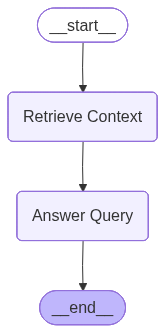

In [9]:
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))